In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -q install -U "transformers==4.57.3" "accelerate==1.10.1" "datasets==4.5.0" "evaluate==0.4.6" "scikit-learn==1.8.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 144.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 57.6 MB/s eta 0:00:00


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"   # 防止 wandb 跳出來

import transformers, accelerate, datasets, evaluate, sklearn
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("sklearn:", sklearn.__version__)


transformers: 4.57.3
accelerate: 1.10.1
datasets: 4.5.0
evaluate: 0.4.6
sklearn: 1.8.0


In [ ]:
from accelerate.state import AcceleratorState
from accelerate import Accelerator

# 先清掉殘狀態，立刻用 Accelerator 建回完整 state
AcceleratorState._reset_state()
acc = Accelerator(mixed_precision="no")
print("Accelerate ok:", acc.state.distributed_type, acc.state.mixed_precision)


Accelerate ok: DistributedType.NO no


In [ ]:
# =====================================================
# 1. 讀取 train / val / test 三個檔案
# =====================================================
import pandas as pd
from datasets import Dataset, DatasetDict

train_path = "/content/drive/MyDrive/train.csv"
val_path   = "/content/drive/MyDrive/val.csv"
test_path  = "/content/drive/MyDrive/test.csv"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

# 保險起見，再把 label 強制轉 0/1，轉不成數字的丟掉
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    before = len(df)
    df.dropna(subset=["label"], inplace=True)
    df["label"] = df["label"].astype(int)
    print(f"{name} 集：清理掉 {before - len(df)} 筆非 0/1 label，剩 {len(df)} 筆")

print("\nTrain label 分布：")
print(train_df["label"].value_counts())

# 只保留 text, label 欄位（urls 先不用）
train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds   = Dataset.from_pandas(val_df[["text", "label"]])
test_ds  = Dataset.from_pandas(test_df[["text", "label"]])

raw_datasets = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})
raw_datasets


train 集：清理掉 0 筆非 0/1 label，剩 134388 筆
val 集：清理掉 0 筆非 0/1 label，剩 28797 筆
test 集：清理掉 0 筆非 0/1 label，剩 28798 筆

Train label 分布：
label
0    74343
1    60045
Name: count, dtype: int64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 134388
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 28797
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 28798
    })
})

In [ ]:
from collections import Counter
print("Train:", Counter(raw_datasets["train"]["label"]))
print("Val:", Counter(raw_datasets["validation"]["label"]))
print("Test:", Counter(raw_datasets["test"]["label"]))


Train: Counter({0: 74343, 1: 60045})
Val: Counter({0: 15930, 1: 12867})
Test: Counter({0: 15931, 1: 12867})


In [ ]:
# =====================================================
# 2. 準備 DeBERTa-v3-base 模型與 tokenizer
# =====================================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "microsoft/deberta-v3-base"   #⭐ 可改成 "deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

max_length = 512  # 郵件長度通常 512 夠用，之後需要可以再調整

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )

tokenized_datasets = raw_datasets.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],  # text 被轉成 input_ids / attention_mask
)

tokenized_datasets


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/134388 [00:00<?, ? examples/s]

Map:   0%|          | 0/28797 [00:00<?, ? examples/s]

Map:   0%|          | 0/28798 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 134388
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 28797
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 28798
    })
})

In [ ]:
# =====================================================
# 3. 建立分類模型
# =====================================================
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,   # 0: non-phishing, 1: phishing
    hidden_dropout_prob=0.2,       # ⭐ encoder dropout
    attention_probs_dropout_prob=0.2,   # ⭐ attention dropout
)


pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# =====================================================
# 4. 定義評估指標
# =====================================================
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


In [ ]:
# =====================================================
# 5. 設定 TrainingArguments（4.57.3 新版寫法）
# =====================================================
from transformers import TrainingArguments, Trainer
from transformers import EarlyStoppingCallback

batch_size = 64        # 若爆 VRAM 就改 4 或 2  #⭐ batch_size 64
logging_steps = 200

training_args = TrainingArguments(
    output_dir="/content/deberta-phishing-cls",

    # ⭐ 在 4.57.3 裡要用 eval_strategy，不能再用 evaluation_strategy
    eval_strategy="epoch",          # 每個 epoch 做一次 evaluate
    save_strategy="epoch",          # 每個 epoch 存一次 checkpoint

    learning_rate=2e-5,  # ⭐原2e-5
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=5, # False
    weight_decay=0.01,  #原0.01⭐這就是標準的 L2 regularization

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    logging_steps=logging_steps,
    fp16=False, # ⭐改為False
    bf16=True,  # ⭐新增
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args, # ⭐
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    #tokenizer=tokenizer, #⭐
    compute_metrics=compute_metrics,
)

# ⭐ 加 Early Stopping（關鍵）
trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=1)) #⭐

In [ ]:
import torch
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        # 先存成 CPU tensor 就好
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        model_inputs = {k: v for k, v in inputs.items() if k != "labels"}

        outputs = model(**model_inputs)
        logits = outputs.logits

        # ⭐ 關鍵：在這裡對齊 device
        weight = self.class_weights.to(logits.device)

        loss_fct = torch.nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


In [ ]:
import torch

class_weights = torch.tensor([1.0, 1.2]).to(model.device)

loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)


In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, EarlyStoppingCallback
)
import evaluate

# ====== 0) 你的資料：df 需包含 text, label ======
# df = pd.read_csv("/content/drive/MyDrive/all_emails_clean.csv")
# df = df[df["label"].isin([0,1])].copy()
# df["label"] = df["label"].astype(int)

MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256
    )

# ====== 1) Metrics ======
acc = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision.compute(predictions=preds, references=labels, average="binary")["precision"],
        "recall": recall.compute(predictions=preds, references=labels, average="binary")["recall"],
        "f1": f1.compute(predictions=preds, references=labels, average="binary")["f1"],
    }

# ====== 2) 你的 WeightedTrainer（沿用你現在的版本） ======
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels").long()
        model_inputs = {k: v for k, v in inputs.items() if k != "labels"}
        outputs = model(**model_inputs)
        logits = outputs.logits
        weight = self.class_weights.to(logits.device)
        loss_fct = torch.nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ====== 3) K-fold 設定 ======
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

X = df["text"].values
y = df["label"].values

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n========== Fold {fold}/{K} ==========")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    # 每個 fold 的 class weight 都用該 fold 的 train 計算（避免 leakage）
    cw = compute_class_weight(class_weight="balanced", classes=np.array([0,1]), y=train_df["label"].values)
    class_weights = torch.tensor(cw, dtype=torch.float)

    train_ds = Dataset.from_pandas(train_df[["text","label"]]).rename_column("label", "labels")
    val_ds   = Dataset.from_pandas(val_df[["text","label"]]).rename_column("label", "labels")

    train_ds = train_ds.map(tokenize_fn, batched=True).remove_columns(["text"])
    val_ds   = val_ds.map(tokenize_fn, batched=True).remove_columns(["text"])

    # 重新初始化模型（每個 fold 必須從頭訓練）
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    args = TrainingArguments(
        output_dir=f"/content/deberta_kfold/fold_{fold}",
        learning_rate=1e-5,                  # 你可以逐一測
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=10,                 # 讓 early stopping 決定何時停
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        weight_decay=0.01,
        logging_steps=200,
        report_to="none",
        fp16=torch.cuda.is_available(),
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        class_weights=class_weights,
    )

    trainer.train()
    metrics = trainer.evaluate()

    # 記錄 fold 結果
    fold_results.append({
        "fold": fold,
        "eval_loss": metrics.get("eval_loss"),
        "eval_accuracy": metrics.get("eval_accuracy"),
        "eval_precision": metrics.get("eval_precision"),
        "eval_recall": metrics.get("eval_recall"),
        "eval_f1": metrics.get("eval_f1"),
    })

# ====== 4) 輸出平均表現 ======
res_df = pd.DataFrame(fold_results)
print("\n===== K-Fold Summary =====")
print(res_df)
print("\nMean:")
print(res_df.mean(numeric_only=True))
print("\nStd:")
print(res_df.std(numeric_only=True))


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



========== Fold 1/5 ==========


Map:   0%|          | 0/23038 [00:00<?, ? examples/s]

Map:   0%|          | 0/5760 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3004759324.py:50: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


...

Map:   0%|          | 0/23039 [00:00<?, ? examples/s]

Map:   0%|          | 0/5759 [00:00<?, ? examples/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3004759324.py:50: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.110200,0.072434,0.980552,0.992003,0.964244,0.977927
2,0.036300,0.060495,0.987151,0.991736,0.979401,0.985530
3,0.040000,0.086679,0.987498,0.994464,0.977458,0.985888
4,0.023700,0.056321,0.988713,0.989844,0.984843,0.987337
5,0.004400,0.104797,0.987151,0.992899,0.978236,0.985513
6,0.010000,0.106652,0.988887,0.992927,0.982122,0.987495
7,0.000000,0.183714,0.983157,0.997189,0.965021,0.980841
8,0.000000,0.091332,0.990276,0.993723,0.984454,0.989067
9,0.004300,0.094289,0.989061,0.988327,0.987175,0.987750
10,0.000000,0.133016,0.986630,0.996025,0.973960,0.984869



===== K-Fold Summary =====
   fold  eval_loss  eval_accuracy  eval_precision  eval_recall   eval_f1
0     1   0.140092       0.986979        0.993678     0.977078  0.985309
1     2   0.110994       0.982118        0.989695     0.970085  0.979792
2     3   0.069251       0.987847        0.988676     0.984065  0.986365
3     4   0.123287       0.988366        0.996434     0.977458  0.986855
4     5   0.091332       0.990276        0.993723     0.984454  0.989067

Mean:
fold              3.000000
eval_loss         0.106991
eval_accuracy     0.987117
eval_precision    0.992441
eval_recall       0.978628
eval_f1           0.985478
dtype: float64

Std:
fold              1.581139
eval_loss         0.027599
eval_accuracy     0.003045
eval_precision    0.003195
eval_recall       0.005921
eval_f1           0.003461
dtype: float64


In [ ]:
all_probs = []
all_labels = []


In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

probs = trainer.predict(val_ds).predictions
probs = torch.softmax(torch.tensor(probs), dim=1).numpy()
y_true = val_df["label"].values

# 只存 phishing 類別機率
y_prob = probs[:, 1]

all_probs.extend(y_prob)
all_labels.extend(y_true)


In [ ]:
all_logits = []
all_labels = []


In [ ]:
pred_output = trainer.predict(val_ds)

logits = pred_output.predictions
labels = pred_output.label_ids

all_logits.append(logits)
all_labels.append(labels)


In [ ]:
import numpy as np

all_logits = np.vstack(all_logits)
all_labels = np.concatenate(all_labels)

print(all_logits.shape)  # (N, 2)
print(all_labels.shape)  # (N,)


(5759, 2)
(5759,)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

logits = torch.tensor(all_logits, dtype=torch.float32)
labels = torch.tensor(all_labels, dtype=torch.long)

class TempScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.T = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, logits):
        return logits / self.T.clamp(min=1e-3)

scaler = TempScaler()
criterion = nn.CrossEntropyLoss()
optimizer = optim.LBFGS([scaler.T], lr=0.1, max_iter=200)

def closure():
    optimizer.zero_grad()
    loss = criterion(scaler(logits), labels)
    loss.backward()
    return loss

optimizer.step(closure)

T = scaler.T.item()
print("Best Temperature:", T)


Best Temperature: 2.7458763122558594


In [ ]:
with torch.no_grad():
    calibrated_probs = torch.softmax(scaler(logits), dim=1)[:,1].numpy()


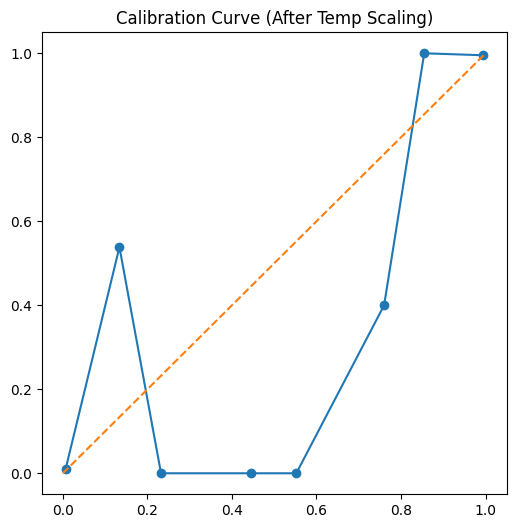

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    all_labels, calibrated_probs, n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.title("Calibration Curve (After Temp Scaling)")
plt.show()


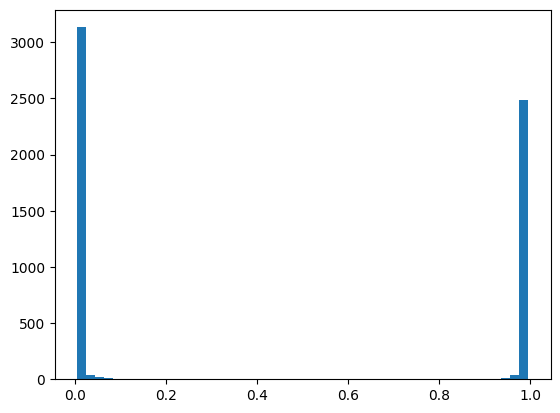

In [ ]:
plt.hist(calibrated_probs, bins=50)
plt.show()


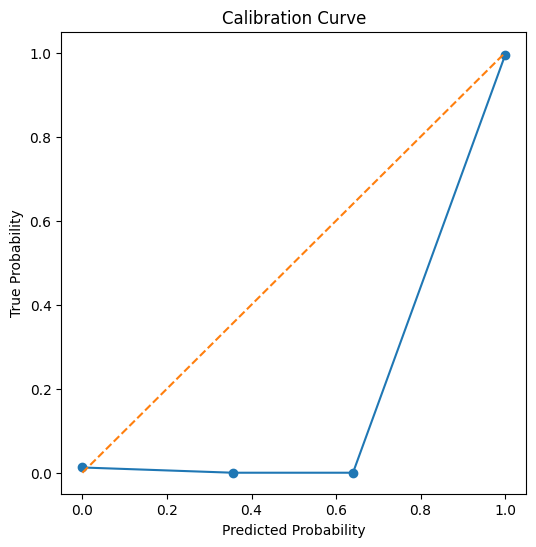

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    all_labels, all_probs, n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()


In [ ]:
# 每次重建 trainer 前，把 metrics 的 printed reset（讓你看得到 pred 分布）
if hasattr(compute_metrics, "printed"):
    delattr(compute_metrics, "printed")

trainer = WeightedTrainer(
    model=model,
    args=training_args, # ⭐
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

print("Trainer type:", type(trainer))

train_result = trainer.train()
print("✅ 訓練完成（短訓練驗證）")


Trainer type: <class '__main__.WeightedTrainer'>


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.014800,0.027988,0.992916,0.996005,0.988109,0.992041
2,0.008500,0.059764,0.989166,0.997622,0.978083,0.987756


KeyboardInterrupt: 

In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback

training_args_full = TrainingArguments(
    output_dir="/content/deberta-phishing-cls",
    learning_rate=2e-5,
    per_device_train_batch_size=8, # ⭐
    per_device_eval_batch_size=8,

    num_train_epochs=3,          # ⭐先3 epochs，通常夠
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    weight_decay=0.01,           # ⭐L2 正則化，抗 overfit
    label_smoothing_factor=0.1,  # 你目前有效，先保留
    report_to="none",
    logging_steps=200,

    fp16=False,                  # 等一切穩再開
)


In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args_full,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)


In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.050300,0.080220,0.988107,0.996613,0.977732,0.987083
2,0.027800,0.035778,0.992871,0.996294,0.988336,0.992299
3,0.004400,0.045430,0.993462,0.996370,0.989538,0.992942


TrainOutput(global_step=53268, training_loss=0.03389751150953882, metrics={'train_runtime': 4326.7213, 'train_samples_per_second': 98.486, 'train_steps_per_second': 12.311, 'total_flos': 5.64494160180695e+16, 'train_loss': 0.03389751150953882, 'epoch': 3.0})

In [ ]:
test_metrics = trainer.evaluate(tokenized_datasets["test"])
print(test_metrics)


{'eval_loss': 0.04217109456658363, 'eval_accuracy': 0.9940206321046061, 'eval_precision': 0.9963036678987773, 'eval_recall': 0.990810123002969, 'eval_f1': 0.9935493017650812, 'eval_runtime': 96.9402, 'eval_samples_per_second': 313.987, 'eval_steps_per_second': 39.251, 'epoch': 3.0}


In [ ]:
import numpy as np

# 取得 test set 預測
pred_output = trainer.predict(tokenized_datasets["test"])

logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=1)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)


y_true shape: (30438,)
y_pred shape: (30438,)


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
cm


array([[16240,    52],
       [  130, 14016]])

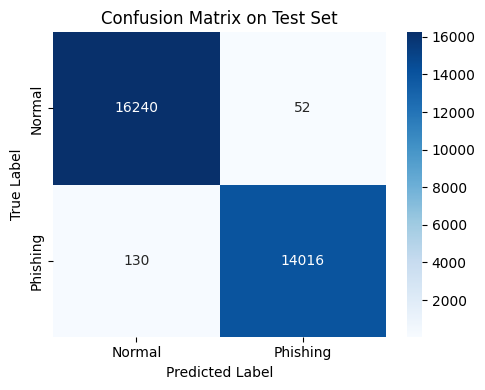

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["Normal", "Phishing"]

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


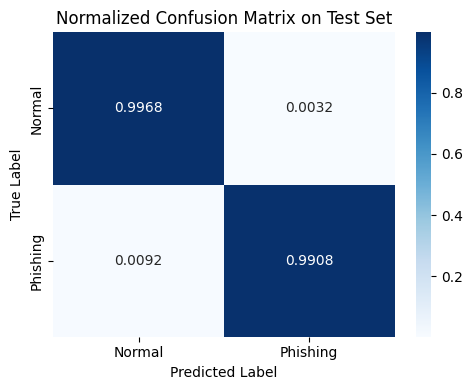

In [ ]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".4f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Phishing"],
    digits=4
))


              precision    recall  f1-score   support

      Normal     0.9921    0.9968    0.9944     16292
    Phishing     0.9963    0.9908    0.9935     14146

    accuracy                         0.9940     30438
   macro avg     0.9942    0.9938    0.9940     30438
weighted avg     0.9940    0.9940    0.9940     30438

